# Grammar Scoring Engine for Spoken English
**SHL Hiring Assessment 2026** · predict a 1–5 grammar score (averaged rater MOS) from a 45–60 s spoken answer.

**Approach.** Transcribe with Whisper, then combine *what was said* (grammar-aware text models on the transcript)
with *how it was said* (the Whisper speech encoder, adapted to the task with LoRA) in a small, cross-validated stack.

**How to read this notebook.** Every number shown is computed in a code cell below:
* CPU steps (features, TF-IDF, stacking, evaluation) run here, live.
* GPU steps (speech recognition, grammar models, DeBERTa and Whisper fine-tuning) are separate scripts in `src/`.
  For each one, this notebook shows the script's actual training code, the command that ran it, its training log
  (`results/logs/`), and **recomputes its score from its saved out-of-fold predictions against the true labels**.
  Set `RUN_GPU = True` to re-run those scripts from here instead of loading their saved outputs.
* The last section checks that the notebook reproduces the submitted file (`results/sub06_…csv`) exactly.

In [1]:
import json, re, subprocess, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src")
import stacking as S                     # model building blocks (level-1 models, NNLS stack, metrics)
from features import load as load_features

RUN_GPU = False                          # True: re-run the GPU scripts (hours); False: load their saved outputs
DATA, OUT, LOGS = "data/Dataset_Final", "outputs", "results/logs"
TRANSCRIPTS, LABELS = f"{OUT}/transcripts_fw_large_v3.jsonl", f"{DATA}/train.csv"
pd.set_option("display.width", 170, "display.max_colwidth", 100, "display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
warnings.filterwarnings("ignore")        # library deprecation / numerical notices; results are unaffected

def gpu_step(cmd, output):
    # Run a GPU script if RUN_GPU is set, otherwise use its saved output.
    if RUN_GPU:
        subprocess.run([sys.executable, *cmd.split()], check=True)
    print(f"{'ran' if RUN_GPU else 'using saved output of'}: python {cmd}\n  -> {output} ({'found' if Path(output).exists() else 'MISSING'})")

def show_code(path, start, end):
    # Print the block of a script between two marker lines - the exact code that produced the saved outputs.
    lines = Path(path).read_text(encoding="utf-8").splitlines()
    i = next(n for n, l in enumerate(lines) if start in l)
    j = next(n for n, l in enumerate(lines[i:], i) if end in l)
    print(f"# {path}, lines {i + 1}-{j + 1}\n" + "\n".join(lines[i:j + 1]))

def training_log(name):
    # Parse a GPU training log: final-epoch validation RMSE per fold for every run, and the run's OOF score.
    p = Path(LOGS) / name
    if not p.exists():
        print(f"(log {p} not found)"); return None
    runs, cur = [], {}
    for line in p.read_text(encoding="utf-8").splitlines():
        m = re.match(r"fold (\d+) epoch (\d+): val RMSE ([\d.]+)", line)
        if m:
            cur[int(m[1])] = float(m[3])                     # keeps the last (= final) epoch of each fold
        m = re.match(r"OOF RMSE ([\d.]+)\s+r ([\d.]+)", line)
        if m:
            runs.append({**{f"fold {k}": v for k, v in sorted(cur.items())}, "logged OOF RMSE": float(m[1]), "logged OOF r": float(m[2])})
            cur = {}
    return pd.DataFrame(runs, index=[f"{name} run {i + 1}" for i in range(len(runs))])

def rescore(csv, labels):
    # Recompute RMSE / Pearson r of a saved out-of-fold prediction file against the true labels.
    p = pd.read_csv(csv); p = p[p.split == "train"].merge(labels, on="filename")
    y, q = p.label.values, p.iloc[:, 2].values
    return round(float(np.sqrt(np.mean((y - q) ** 2))), 3), round(float(np.corrcoef(y, q)[0, 1]), 3)

## 1. The data — and three findings that shape the approach
769 labelled training clips, 216 test clips. Rubric levels 1–5 (1 = struggles with basic sentence structure …
5 = accurate, handles complex grammar, self-corrects).

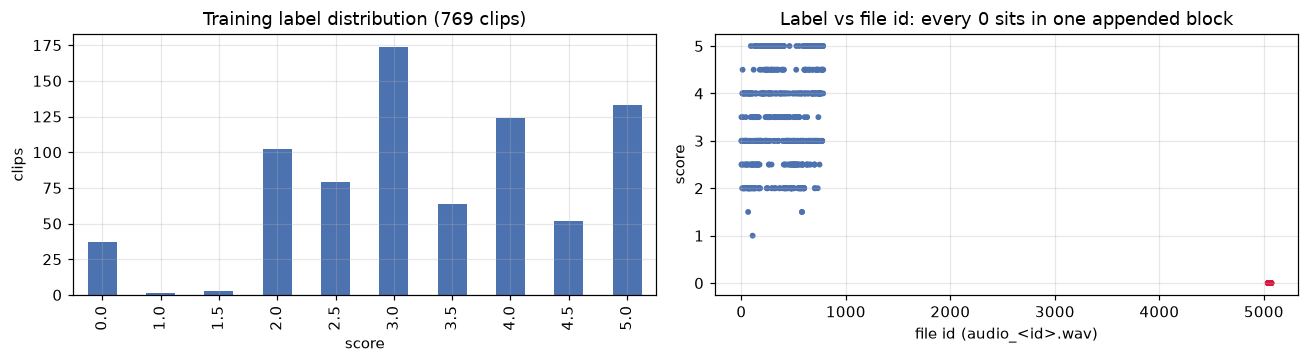

zero labels: 37, ids 5037..5073 (contiguous: True)
all other training clips: 732, ids 0..784, mean score 3.48
test clips: ids 0..215


In [2]:
lab = pd.read_csv(LABELS)
lab["id"] = lab.filename.str.extract(r"(\d+)").astype(int)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
lab.label.value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set(title=f"Training label distribution ({len(lab)} clips)", xlabel="score", ylabel="clips")
ax[1].scatter(lab.id, lab.label, s=8, c=np.where(lab.label == 0, "crimson", "#4C72B0"))
ax[1].set(title="Label vs file id: every 0 sits in one appended block", xlabel="file id (audio_<id>.wav)", ylabel="score")
plt.tight_layout(); plt.show()
zeros, valid = lab[lab.label == 0], lab[lab.label > 0]
test_ids = pd.read_csv(f"{DATA}/test.csv").filename.str.extract(r"(\d+)").astype(int)[0]
print(f"zero labels: {len(zeros)}, ids {zeros.id.min()}..{zeros.id.max()} (contiguous: {zeros.id.max() - zeros.id.min() + 1 == len(zeros)})")
print(f"all other training clips: {len(valid)}, ids {valid.id.min()}..{valid.id.max()}, mean score {valid.label.mean():.2f}")
print(f"test clips: ids {test_ids.min()}..{test_ids.max()}")

**Finding 1 — the zero labels are missing ratings, not grammar scores.** 0 is not a rubric level, all zeros form one
contiguous block of file ids appended after the normal files, their transcripts (§3) are ordinary speech, and the test
ids do not reach that block. They are **excluded from training and validation**; the effect on the metric is shown in §7.

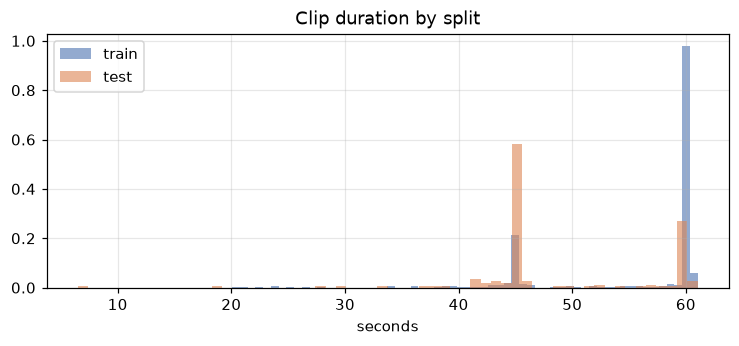

split  test share  train share
batch                         
45s          0.56         0.16
60s          0.27         0.72
other        0.18         0.12
       count  mean   std
batch                   
45s      124  3.04  0.88
60s      521  3.58  1.02
other     87  3.52  0.97


In [3]:
tx = pd.DataFrame([json.loads(l) for l in open(TRANSCRIPTS, encoding="utf-8")])   # ASR output (see §3) incl. duration
tx["batch"] = S.batch_of(tx.duration)
fig, ax = plt.subplots(figsize=(8, 3))
for s, c in (("train", "#4C72B0"), ("test", "#DD8452")):
    ax.hist(tx[tx.split == s].duration, bins=60, alpha=.6, density=True, label=s, color=c)
ax.set(title="Clip duration by split", xlabel="seconds"); ax.legend(); plt.show()
print(pd.crosstab(tx.batch, tx.split, normalize="columns").round(2).rename(columns=lambda c: f"{c} share"))
print(tx[tx.split == "train"].merge(valid, on="filename").groupby("batch").label.agg(["count", "mean", "std"]).round(2))

**Finding 2 — two recording batches, and the test set is dominated by the one that is rare in training.** The ~45 s
batch also has lower, less spread-out scores. Therefore all hand-crafted features are length-normalised, the CV folds are
stratified by batch, every model is also scored on the 45 s subset and with a **test-mix RMSE** (errors re-weighted by
test share / train share of each clip's batch — our leaderboard proxy), and the final fit uses the same weights.

## 2. Pipeline
```
 wav ─► faster-whisper large-v3 ─► transcript + word timings + confidences
  │                                 ├─► fluency & text features ───────────────────────────┐
  │                                 ├─► CoLA acceptability + grammar-correction edit rate ──┴─► gradient boosting / ridge
  │                                 ├─► TF-IDF ─► ridge
  │                                 └─► DeBERTa-v3-large fine-tuned regressor (5 folds × 3 seeds)
  └─► Whisper-large-v3 encoder + LoRA adapters ─► regression head (5 folds)
          every level-1 model predicts out-of-fold ─► non-negative weighted average (level 2, nested CV)
```
The neural models are fine-tuned for a fixed number of epochs (no per-fold early stopping), so their out-of-fold
predictions are honest; the Whisper encoder only through LoRA adapters (<1 % of its weights) — the right capacity
for ~730 labels. Speech recognition and the CoLA / grammar-correction models are used frozen.

## 3. Speech recognition (GPU) — and what it hides

In [4]:
gpu_step("src/transcribe_fw.py", TRANSCRIPTS)
show_code("src/transcribe_fw.py", "segs, _ = model.transcribe", "segs = list(segs)")
tr_tx = tx[tx.split == "train"].merge(valid, on="filename")
print(f"\n{len(tx)} clips transcribed, {tx.text.str.split().str.len().mean():.0f} words per clip on average")
for _, r in tr_tx.sort_values("label").iloc[[5, len(tr_tx) // 2, -5]].iterrows():
    print(f"score {r.label}: " + " ".join(r.text.split()[:26]) + " ...")
words = tx.text.str.lower().str.findall(r"[a-z']+")
fill = words.apply(lambda w: sum(t in {"um", "uh", "er", "erm", "ah", "hmm"} for t in w) / max(len(w), 1) * 100)
print(f"\nfilled pauses (um/uh/...) per 100 words: mean {fill.mean():.3f}; clips containing any: {(fill > 0).mean():.1%}")

using saved output of: python src/transcribe_fw.py
  -> outputs/transcripts_fw_large_v3.jsonl (found)
# src/transcribe_fw.py, lines 50-52
        segs, _ = model.transcribe(x, language="en", beam_size=5, word_timestamps=True,
                                   condition_on_previous_text=False)
        segs = list(segs)

985 clips transcribed, 100 words per clip on average
score 2.0: My hobby is watching TV and web series and movies. I like the most about the NTR and his movies and his action. I like to ...
score 3.5: life is full of events both good and bad some things will be forgotten over time and some will stay in our heart forever our life ...
score 5.0: Well, my favorite hobby is music, so yeah, I love playing music. I have a bass, I play bass. I like to kind of play with ...

filled pauses (um/uh/...) per 100 words: mean 0.258; clips containing any: 12.0%


**Finding 3 — Whisper cleans up speech.** It keeps repetitions but drops almost every filled pause, so filler
features computed from the transcript are nearly empty. The audio branch (§5) hears hesitations directly.

## 4. Hand-crafted fluency and grammar features

using saved output of: python src/grammar_features.py --transcripts outputs/transcripts_fw_large_v3.jsonl
  -> outputs/grammar_features.csv (found)
# src/grammar_features.py, lines 43-49
def edits(src, tgt):
    s, t = words(src), words(tgt)
    ops = {"insert": 0, "delete": 0, "replace": 0}
    for op, i1, i2, j1, j2 in difflib.SequenceMatcher(None, s, t, autojunk=False).get_opcodes():
        if op != "equal":
            ops[op] += max(i2 - i1, j2 - j1)
    return ops


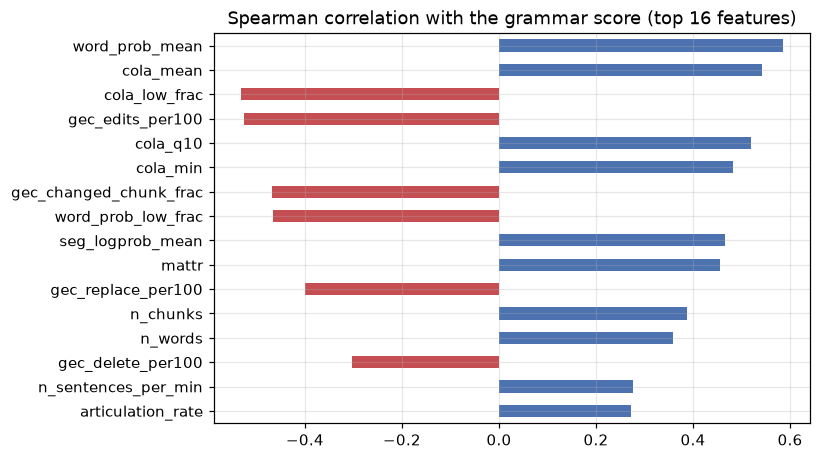

spoken   : there was a day in the airport that I wanted to go with my mom to Panama in this day I was trying to buy
corrected: There was a day at the airport that I wanted to go with my mom to Panama. On this day, I was trying to buy 

spoken   : A lot of noise are in there.
corrected: A lot of noise is in there. 

spoken   : So if you are not good at noises, it is not for you.
corrected: So if you are not good at noise, it is not for you. 



In [5]:
gpu_step("src/grammar_features.py --transcripts " + TRANSCRIPTS, f"{OUT}/grammar_features.csv")
show_code("src/grammar_features.py", "def edits(src, tgt)", "return ops")
feats, _ = load_features(TRANSCRIPTS)                                   # src/features.py, computed here
feats = feats.merge(pd.read_csv(f"{OUT}/grammar_features.csv"), on=["filename", "split"])
ft = feats[feats.split == "train"].merge(valid, on="filename")
corr = ft.drop(columns=["filename", "split", "label", "id"]).corrwith(ft.label, method="spearman").dropna()
corr = corr.reindex(corr.abs().sort_values().index)[-16:]
corr.plot.barh(figsize=(7, 4.6), color=np.where(corr > 0, "#4C72B0", "#C44E52"),
               title="Spearman correlation with the grammar score (top 16 features)"); plt.show()
pairs = [json.loads(l) for l in open(f"{OUT}/gec_corrections.jsonl", encoding="utf-8")]
shown = 0
for p in pairs:
    for src, tgt in p["pairs"]:
        s, t = re.findall(r"[a-z']+", src.lower()), re.findall(r"[a-z']+", tgt.lower())
        if len(s) == len(t) and 0 < sum(a != b for a, b in zip(s, t)) <= 2 and shown < 3:
            print("spoken   :", src[:110]); print("corrected:", tgt[:110], "\n"); shown += 1

The **grammar-correction edit rate** (word edits per 100 words by CoEdIT, punctuation and capitalisation ignored)
and **CoLA acceptability** are among the strongest single features, next to delivery measures (speech rate, pauses)
and ASR confidence.

## 5. Neural components (GPU): code, training logs, and re-scored predictions
For each component: the core training loop (read from the script), its training log (final-epoch validation RMSE per
fold, per run), and its out-of-fold score **recomputed here** from the saved predictions — which must match the log.

In [6]:
LORA = [f"{OUT}/whisper_ft_preds.csv", f"{OUT}/whisper_ft_s100.csv", f"{OUT}/whisper_ft_s200.csv"]
DEB_L = [f"{OUT}/deberta_large_preds.csv", f"{OUT}/deberta_large_s1.csv", f"{OUT}/deberta_large_s2.csv"]
DEB_B = [f"{OUT}/deberta_preds.csv", f"{OUT}/deberta_base_s1.csv", f"{OUT}/deberta_base_s2.csv"]
PAUSE = [f"{OUT}/deberta_large_pause_s{s}.csv" for s in (0, 100, 200)]

# --- DeBERTa-v3-large regressor on the transcript (3 seeds) ---
for seed, out in zip((0, 100, 200), DEB_L):
    gpu_step(f"src/text_model.py --model microsoft/deberta-v3-large --lr 1e-5 --seed {seed} --out {out}", out)
show_code("src/text_model.py", "for k in sorted(tr.fold.unique())", "test_pred += predict")
print()
print(pd.concat([training_log("deberta_large_seed0.log"), training_log("deberta_base_large_seeds100_200.log")]))
print("\nre-scored from saved predictions (RMSE, r):", {Path(f).stem: rescore(f, valid) for f in DEB_L + DEB_B})

using saved output of: python src/text_model.py --model microsoft/deberta-v3-large --lr 1e-5 --seed 0 --out outputs/deberta_large_preds.csv
  -> outputs/deberta_large_preds.csv (found)
using saved output of: python src/text_model.py --model microsoft/deberta-v3-large --lr 1e-5 --seed 100 --out outputs/deberta_large_s1.csv
  -> outputs/deberta_large_s1.csv (found)
using saved output of: python src/text_model.py --model microsoft/deberta-v3-large --lr 1e-5 --seed 200 --out outputs/deberta_large_s2.csv
  -> outputs/deberta_large_s2.csv (found)
# src/text_model.py, lines 81-104
for k in sorted(tr.fold.unique()):
    torch.manual_seed(a.seed + k)
    trn, val = tr[tr.fold != k], tr[tr.fold == k]
    # fp32 master weights: the checkpoint is stored in fp16 and transformers 5 would load it as fp16,
    # which makes AdamW updates underflow -> NaN. Mixed precision comes from autocast below.
    model = AutoModelForSequenceClassification.from_pretrained(a.model, num_labels=1, dtype=torch.float32

In [7]:
# --- Whisper-large-v3 encoder fine-tuned with LoRA (3 seeds; seed 0 is used in the final model) ---
for seed, out in zip((0, 100, 200), LORA):
    gpu_step(f"src/audio_finetune.py --seed {seed} --out {out}", out)
show_code("src/audio_finetune.py", "class Scorer", "return self.head")
print()
print(pd.concat([training_log(f"lora_whisper_seed{s}.log") for s in (0, 100, 200)]))
print("\nre-scored from saved predictions (RMSE, r):", {Path(f).stem: rescore(f, valid) for f in LORA})

using saved output of: python src/audio_finetune.py --seed 0 --out outputs/whisper_ft_preds.csv
  -> outputs/whisper_ft_preds.csv (found)
using saved output of: python src/audio_finetune.py --seed 100 --out outputs/whisper_ft_s100.csv
  -> outputs/whisper_ft_s100.csv (found)
using saved output of: python src/audio_finetune.py --seed 200 --out outputs/whisper_ft_s200.csv
  -> outputs/whisper_ft_s200.csv (found)
# src/audio_finetune.py, lines 61-78
class Scorer(torch.nn.Module):
    def __init__(self):
        super().__init__()
        enc = WhisperModel.from_pretrained(a.model, dtype=torch.float32).get_encoder()
        enc.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
        self.enc = get_peft_model(enc, LoraConfig(r=a.rank, lora_alpha=2 * a.rank, lora_dropout=0.1,
                                                  target_modules=["q_proj", "v_proj"]))
        self.head = torch.nn.Sequential(torch.nn.LayerNorm(1280), torch.nn.Dropout(0.1), torc

In [8]:
# --- frozen speech encoders + ridge (ablation only): CPU, re-run live from the saved embeddings ---
for emb, layers, out in [("whisper_enc_emb", "25,26,27,28,29,30,31,32", "whisper_enc_preds"),
                         ("wavlm_emb", "6,7,8,9", "wavlm_preds"),
                         ("wavlm_large_emb", "13,14,15,16,17,18,19,20", "wavlm_large_preds")]:
    log = subprocess.run([sys.executable, "-W", "ignore", "src/audio_model.py", "--emb", f"{OUT}/{emb}.npz", "--labels", LABELS,
                          "--folds", f"{OUT}/folds.csv", "--layers", layers, "--out", f"{OUT}/{out}.csv"],
                         capture_output=True, text=True, check=True).stdout
    print(f"{emb:16s} -> " + [l for l in log.splitlines() if "used" in l][0])

whisper_enc_emb  -> layers [25, 26, 27, 28, 29, 30, 31, 32] (used): OOF RMSE 0.556  r 0.836


wavlm_emb        -> layers [6, 7, 8, 9] (used): OOF RMSE 0.598  r 0.808


wavlm_large_emb  -> layers [13, 14, 15, 16, 17, 18, 19, 20] (used): OOF RMSE 0.560  r 0.834


## 6. The stack (CPU, computed here)
Level 1 needs two more components computed right here — the hand-crafted features model and TF-IDF — then every
component is an out-of-fold prediction on the same folds. Level 2 is a non-negative weighted average with a free
intercept (weighted least squares with the batch importance weights). Its score is **nested**: the weights used to
predict fold *k* are fit on the other four folds only.

In [9]:
EXTRA = [f"{OUT}/grammar_features.csv"] + DEB_L + DEB_B + PAUSE + LORA + \
        [f"{OUT}/{f}.csv" for f in ("whisper_enc_preds", "wavlm_preds", "wavlm_large_preds")]
AVG = ["deberta_large=deberta_large_preds,deberta_large_s1,deberta_large_s2",
       "deberta_base=deberta_preds,deberta_base_s1,deberta_base_s2",
       "deberta_pause=deberta_large_pause_s0,deberta_large_pause_s100,deberta_large_pause_s200"]
tr, te, HAND, PRED = S.load_table(TRANSCRIPTS, LABELS, EXTRA, AVG)
for d in (tr, te):
    d["lora_whisper_3seeds"] = d[["whisper_ft_preds", "whisper_ft_s100", "whisper_ft_s200"]].mean(axis=1)
y, fold = tr.label.values, S.load_folds(tr, f"{OUT}/folds.csv")
w = S.batch_weights(tr, te)                                        # importance weights (test batch mix)
print(f"{len(tr)} training clips, {len(te)} test clips, {len(HAND)} hand-crafted features; batch weights: "
      + ", ".join(f"{b} x{v:.2f}" for b, v in sorted(dict(zip(tr.batch, w)).items())))

# level-1 components computed here: TF-IDF -> ridge, and hand-crafted features -> (gradient boosting + ridge) / 2
comp = {}
comp["tfidf"] = S.oof(S.tfidf_model, tr.text.values, y, fold, w, te.text.values)
hgb = S.oof(S.hgb_model, tr[HAND].values, y, fold, w, te[HAND].values)
rdg = S.oof(S.ridge_model, tr[HAND].values, y, fold, w, te[HAND].values)
comp["hand_features"] = ((hgb[0] + rdg[0]) / 2, (hgb[1] + rdg[1]) / 2)
# neural / audio components: their saved out-of-fold (train) and test predictions
for c in ["deberta_large", "deberta_base", "deberta_pause", "whisper_ft_preds", "lora_whisper_3seeds",
          "whisper_enc_preds", "wavlm_preds", "wavlm_large_preds"]:
    comp[c] = (tr[c].values, te[c].values)

NAMES = {"hand_features": "fluency + grammar features (HGB/ridge)", "tfidf": "TF-IDF + ridge",
         "deberta_large": "DeBERTa-v3-large (3 seeds)", "deberta_base": "DeBERTa-v3-base (3 seeds)",
         "deberta_pause": "DeBERTa-v3-large + pause markers (3 seeds)", "whisper_ft_preds": "Whisper encoder, LoRA (seed 0)",
         "lora_whisper_3seeds": "Whisper encoder, LoRA (3 seeds)", "whisper_enc_preds": "Whisper encoder frozen + ridge",
         "wavlm_preds": "WavLM-base-plus frozen + ridge", "wavlm_large_preds": "WavLM-large frozen + ridge"}
rows = {"baseline: predict the mean": S.metrics(y, np.full(len(y), y.mean()), tr.batch, w)}
rows |= {f"component: {NAMES[c]}": S.metrics(y, comp[c][0], tr.batch, w) for c in NAMES}
pd.DataFrame(rows).T.sort_values("test-mix RMSE", ascending=False)

732 training clips, 216 test clips, 33 hand-crafted features; batch weights: 45s x3.28, 60s x0.38, other x1.48


,CV RMSE,CV r,45s RMSE,45s r,test-mix RMSE
baseline: predict the mean,1.014,NaN,0.986,NaN,0.994
component: TF-IDF + ridge,0.893,0.597,0.773,0.627,0.829
component: fluency + grammar features (HGB/ridge),0.654,0.765,0.671,0.660,0.666
component: WavLM-base-plus frozen + ridge,0.598,0.808,0.736,0.593,0.664
component: WavLM-large frozen + ridge,0.560,0.834,0.672,0.670,0.615
component: DeBERTa-v3-base (3 seeds),0.613,0.807,0.615,0.763,0.611
component: Whisper encoder frozen + ridge,0.556,0.836,0.609,0.723,0.583
component: DeBERTa-v3-large + pause markers (3 seeds),0.584,0.824,0.594,0.771,0.581
component: DeBERTa-v3-large (3 seeds),0.583,0.825,0.587,0.771,0.576
"component: Whisper encoder, LoRA (3 seeds)",0.552,0.839,0.584,0.749,0.567


In [10]:
def stack(parts):
    # Level 2 over the given components: nested-CV predictions, final weights, test predictions.
    P = np.column_stack([comp[c][0] for c in parts]); Pte = np.column_stack([comp[c][1] for c in parts])
    cv = S.nested_stack(P, y, fold, w)
    coef, b0 = S.nnls_weights(P, y, w)
    return {"cv": cv, "in_sample": b0 + P @ coef, "test": b0 + Pte @ coef, "weights": dict(zip(parts, coef)), "intercept": b0}

FINAL = ["hand_features", "tfidf", "whisper_ft_preds", "deberta_large"]
variants = {
    "text only: features + TF-IDF + DeBERTa-large": ["hand_features", "tfidf", "deberta_large"],
    "audio only: features + TF-IDF + LoRA-Whisper": ["hand_features", "tfidf", "whisper_ft_preds"],
    "FINAL: features + TF-IDF + DeBERTa-large + LoRA-Whisper": FINAL,
}
results = {name: stack(parts) for name, parts in variants.items()}
final = results["FINAL: features + TF-IDF + DeBERTa-large + LoRA-Whisper"]
pd.DataFrame({name: S.metrics(y, r["cv"], tr.batch, w) for name, r in results.items()}).T

,CV RMSE,CV r,45s RMSE,45s r,test-mix RMSE
text only: features + TF-IDF + DeBERTa-large,0.558,0.836,0.547,0.786,0.546
audio only: features + TF-IDF + LoRA-Whisper,0.542,0.845,0.536,0.793,0.536
FINAL: features + TF-IDF + DeBERTa-large + LoRA-Whisper,0.516,0.861,0.516,0.810,0.510


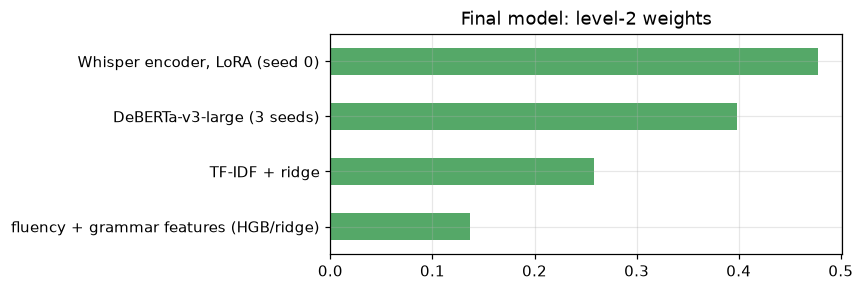

weights sum to 1.27 with intercept -0.93: the stack re-expands predictions that each component shrank toward the mean


In [11]:
wts = pd.Series(final["weights"]).rename(index=NAMES).sort_values()
wts.plot.barh(figsize=(6, 2.6), color="#55A868", title="Final model: level-2 weights"); plt.show()
print(f"weights sum to {wts.sum():.2f} with intercept {final['intercept']:.2f}: the stack re-expands predictions that each "
      "component shrank toward the mean")

Text (DeBERTa) is strongest on the 45 s batch and audio on the 60 s batch, so combining them helps most. Fine-tuning
the Whisper encoder with LoRA — instead of a frozen encoder + ridge — gives the last gain (see the next table).

### Ideas that did not help (computed here, not used in the final model)

In [12]:
def per_batch_recalibration(pred):
    # Re-fit score = a + b * prediction separately per batch (nested over folds, importance-weighted).
    out = np.zeros(len(y)); b = tr.batch.values
    for k in range(S.N_FOLDS):
        for g in np.unique(b):
            t, v = (fold != k) & (b == g), (fold == k) & (b == g)
            A = np.c_[np.ones(t.sum()), pred[t]] * np.sqrt(w[t])[:, None]
            c = np.linalg.lstsq(A, y[t] * np.sqrt(w[t]), rcond=None)[0]
            out[v] = c[0] + c[1] * pred[v]
    return out

X_all = np.column_stack([tr[HAND].values, comp["tfidf"][0], comp["deberta_large"][0], comp["whisper_ft_preds"][0]])
single_level = (S.oof(S.hgb_model, X_all, y, fold, w)[0] + S.oof(S.ridge_model, X_all, y, fold, w)[0]) / 2
tried = {
    "FINAL (for reference)": final["cv"],
    "frozen Whisper encoder + ridge instead of LoRA": stack(["hand_features", "tfidf", "whisper_enc_preds", "deberta_large"])["cv"],
    "LoRA-Whisper averaged over 3 seeds": stack(["hand_features", "tfidf", "lora_whisper_3seeds", "deberta_large"])["cv"],
    "pause markers in the DeBERTa transcripts": stack(["hand_features", "tfidf", "whisper_ft_preds", "deberta_pause"])["cv"],
    "+ DeBERTa-base + WavLM-base/large (7 parts)": stack(FINAL + ["deberta_base", "wavlm_preds", "wavlm_large_preds"])["cv"],
    "per-batch linear recalibration of the output": per_batch_recalibration(final["cv"]),
    "single level: gradient boosting + ridge over all features & predictions": single_level,
}
pd.DataFrame({k: S.metrics(y, v, tr.batch, w) for k, v in tried.items()}).T

,CV RMSE,CV r,45s RMSE,45s r,test-mix RMSE
FINAL (for reference),0.516,0.861,0.516,0.810,0.510
frozen Whisper encoder + ridge instead of LoRA,0.518,0.860,0.524,0.804,0.515
LoRA-Whisper averaged over 3 seeds,0.516,0.861,0.516,0.810,0.511
pause markers in the DeBERTa transcripts,0.517,0.860,0.513,0.813,0.511
+ DeBERTa-base + WavLM-base/large (7 parts),0.513,0.863,0.520,0.807,0.512
per-batch linear recalibration of the output,0.520,0.858,0.525,0.803,0.518
single level: gradient boosting + ridge over all features & predictions,0.526,0.855,0.522,0.806,0.520


We select models by **test-mix RMSE** (our leaderboard proxy). None of these ideas beats the final model on it;
differences of about ±0.002 are within noise, so the simpler model wins. The 7-part stack has a slightly lower plain CV
RMSE but a higher test-mix RMSE: its extra audio encoders help on the 60 s batch, which matters little for the test
set. Pause markers repeat what the audio branch already hears; the out-of-fold predictions are already calibrated in
every batch; one big model over all features overfits ~730 clips where a non-negative weighted average does not; and
seed-averaging the LoRA model changes little because its seeds agree closely (see the training logs in §5).

## 7. Final metrics (including the required training RMSE)

In [13]:
m = S.metrics(y, final["cv"], tr.batch, w)
train_rmse = float(np.sqrt(np.mean((y - final["in_sample"]) ** 2)))
mse_cv = float(np.mean((y - final["cv"]) ** 2))
with_zeros = float(np.sqrt((len(y) * mse_cv + len(zeros) * final["cv"].mean() ** 2) / (len(y) + len(zeros))))
print(f"TRAINING RMSE (final model fit on all {len(y)} valid training clips, scored on those clips): {train_rmse:.3f}")
print("   level 2 is fit on out-of-fold level-1 predictions, so this is an honest in-sample number for the stack")
print(f"CV RMSE (nested 5-fold): {m['CV RMSE']:.3f}   |   CV Pearson r: {m['CV r']:.3f}")
print(f"45 s batch: RMSE {m['45s RMSE']:.3f}, r {m['45s r']:.3f}   |   test-mix-weighted CV RMSE: {m['test-mix RMSE']:.3f}")
print(f"baseline (predict the training mean): RMSE {np.sqrt(np.mean((y - y.mean()) ** 2)):.3f}")
print(f"if the {len(zeros)} zero-labelled clips were scored as real labels, RMSE over all {len(y) + len(zeros)} rows would be ~{with_zeros:.3f}")
print("\nKaggle submissions (results/submissions.csv, public leaderboard RMSE):")
pd.read_csv("results/submissions.csv")[["file", "cv_rmse", "cv_testmix_rmse", "public_lb"]]

TRAINING RMSE (final model fit on all 732 valid training clips, scored on those clips): 0.512
   level 2 is fit on out-of-fold level-1 predictions, so this is an honest in-sample number for the stack
CV RMSE (nested 5-fold): 0.516   |   CV Pearson r: 0.861
45 s batch: RMSE 0.516, r 0.810   |   test-mix-weighted CV RMSE: 0.510
baseline (predict the training mean): RMSE 1.014
if the 37 zero-labelled clips were scored as real labels, RMSE over all 769 rows would be ~0.913

Kaggle submissions (results/submissions.csv, public leaderboard RMSE):


,file,cv_rmse,cv_testmix_rmse,public_lb
0,sub01_v4w_asr-grammar-deberta-wavlm_batchweighted.csv,0.535,0.545,0.366
1,sub02_metricprobe_v4w_x0.5_plus1.5.csv,NaN,NaN,0.463
2,sub03_v8_stack_whisperenc-wavlmL-debertaBL3seeds-grammar.csv,0.515,0.518,0.340
3,sub04_minimal_whisperenc-debertaL3seeds-feats-tfidf.csv,0.518,0.516,0.345
4,sub05_final_minimal_serverenv.csv,0.518,0.515,0.344
5,sub06_final_v9_lora-whisper-debertaL-feats-tfidf.csv,0.516,0.510,0.339


## 8. Error analysis

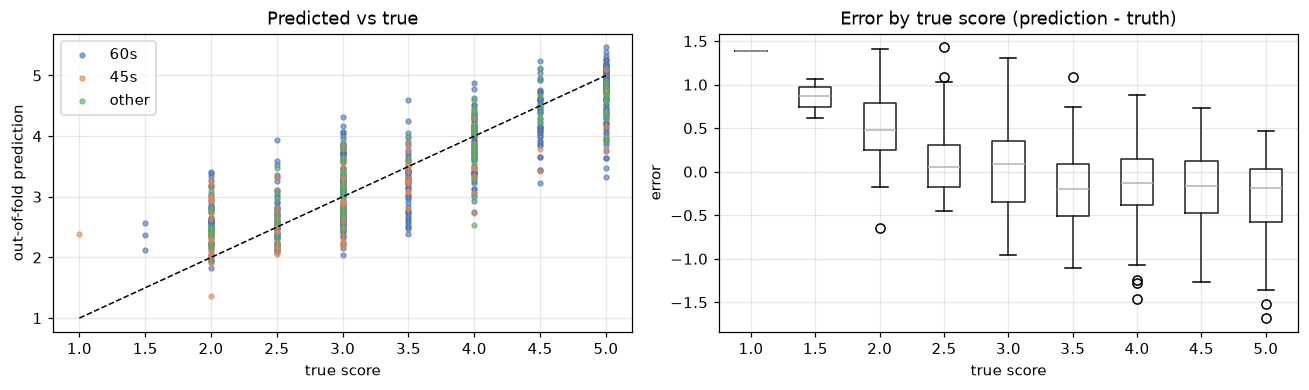

       count  mean_error   rmse
batch                          
45s      124       0.011  0.516
60s      521      -0.018  0.523
other     87       0.029  0.472

largest errors:
true 5.0  pred 3.32  (60s) | I'm gonna describe the scene of a crowded market. There is a market nearby where I live and I mostly ...
true 5.0  pred 3.48  (60s) | my favorite place to visit is the national park I like to visit a national park especially Kruger National Park ...
true 4.0  pred 2.53  (other) | The playground has many children. There are slides, seesaw, and different kind of playing activities. The noise from the playground ...
true 2.5  pred 3.93  (60s) | I think the goal that I am achieving right now is to be happy, completely happy because I think in ...
true 2.0  pred 3.41  (60s) | the school playground is a vibrant space teeming with energy and moment it afforded with colorful equipment like swings lights ...


In [14]:
err = tr[["filename", "batch", "text"]].assign(label=y, pred=final["cv"], err=final["cv"] - y)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for b, c in (("60s", "#4C72B0"), ("45s", "#DD8452"), ("other", "#55A868")):
    s = err[err.batch == b]
    ax[0].scatter(s.label, s.pred, s=10, alpha=.6, label=b, color=c)
ax[0].plot([1, 5], [1, 5], "k--", lw=1); ax[0].set(xlabel="true score", ylabel="out-of-fold prediction", title="Predicted vs true"); ax[0].legend()
err.boxplot(column="err", by="label", ax=ax[1])
ax[1].set(title="Error by true score (prediction - truth)", xlabel="true score", ylabel="error"); plt.suptitle(""); plt.tight_layout(); plt.show()
print(err.groupby("batch").err.agg(count="count", mean_error="mean", rmse=lambda e: np.sqrt(np.mean(e ** 2))).round(3))
print("\nlargest errors:")
for _, r in err.reindex(err.err.abs().sort_values(ascending=False).index).head(5).iterrows():
    print(f"true {r.label}  pred {r.pred:.2f}  ({r.batch}) | " + " ".join(r.text.split()[:20]) + " ...")

* **Regression to the mean** dominates: low scores are over-predicted and 5.0 under-predicted — expected with noisy
  averaged labels and few extreme examples.
* Some misses are speakers who **read prepared text** (e.g. the last one listed, "a vibrant space teeming with
  energy"): polished sentences that raters scored low, since the rubric rewards the speaker's own spontaneous grammar
  ("memorised sentence patterns" = level 1). The largest misses are strong speakers (5.0) scored as average.
* Errors are largest on the 45 s batch, which dominates the test set — the reason for the batch weighting.

## 9. Test predictions and submission check

In [15]:
sub = pd.read_csv(f"{DATA}/test.csv")[["filename"]].merge(
    pd.DataFrame({"filename": te.filename, "label": np.clip(final["test"], 0, 5)}), on="filename")
sub.to_csv(f"{OUT}/submission_final.csv", index=False)
submitted = pd.read_csv("results/sub06_final_v9_lora-whisper-debertaL-feats-tfidf.csv")
diff = (sub.set_index("filename").label - submitted.set_index("filename").label).abs()
assert len(diff) == 216 and diff.max() < 1e-9, "notebook output does not reproduce the submitted file"
print(f"reproduces the submitted file results/sub06_final_v9_lora-whisper-debertaL-feats-tfidf.csv exactly (max |diff| {diff.max():.1e})")
print(sub.label.describe().round(3).to_dict())
sub.head()

reproduces the submitted file results/sub06_final_v9_lora-whisper-debertaL-feats-tfidf.csv exactly (max |diff| 8.9e-16)
{'count': 216.0, 'mean': 3.219, 'std': 0.871, 'min': 1.781, '25%': 2.535, '50%': 3.131, '75%': 3.632, 'max': 5.0}


,filename,label
0,audio_128.wav,2.823
1,audio_156.wav,3.988
2,audio_19.wav,4.600
3,audio_108.wav,1.961
4,audio_206.wav,1.993


## 10. Limitations and next steps
* **Label noise and size**: ~730 averaged ratings with few extreme scores, so predictions shrink toward the middle.
* **ASR is a lossy bottleneck** for the text branch (fillers removed, some errors fixed). A verbatim,
  disfluency-preserving ASR pass would give the text models the evidence raters heard.
* **Read vs spontaneous speech** is a hidden factor the rubric cares about; a detector for it is the most promising
  next feature.
* **Batch shift**: validation is weighted to the test batch mix, but the 45 s batch that dominates test is small in
  training, so estimates there are the noisiest.
* The zero-labelled clips were treated as missing ratings; if they were intentional scores, the model has no signal
  for them, since their speech is ordinary.